In [1]:
import torch
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets, transforms

In [12]:
#로컬에서 확장 colab용 환경설정
# from google.colab import drive
# drive.mount('/content/drive')
# import sys
# sys.path.append('/content/drive/MyDrive/Colab Notebooks/LEVEL 1/torch')
import os
# os.makedirs("/content/results", exist_ok=True)
os.makedirs("/content/data", exist_ok=True)
print(os.getcwd())
# os.chdir("/content/results") #colab클라우드 런타임에 가상폴더 만들고 이동 

# print(os.getcwd())
# from multiclass_functions1 import * # * 은 all을 의미, 따로 로컬 colab에서 파일 우클릭으로 런타임에 업로드해야함
# import torch
# from torch import nn, optim
# from torchvision import datasets, transforms
# import albumentations as A
# from albumentations.pytorch import ToTensorV2
# import cv2
# import matplotlib.pyplot as plt
# import copy
# import numpy as np
import matplotlib.pyplot as plt
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

/content
cuda


In [ ]:
# data 다운(ai hub사이트, 실제데이터를 활용한 포트폴리오 만들기 좋다. kaggle은 데이터가 정제되어있어 모델의 성능을 높이는능력향상에 좋음)
# https://aihub.or.kr/aihubdata/data/view.do?currMenu=115&topMenu=100&aihubDataSe=realm&dataSetSn=126 에서 받을 수 있어요
# 한국어-영어 번역(병렬)말뭉치 데이터(대화체 10만 문장 데이터)
!pip install gdown
!gdown https://drive.google.com/uc?id=14lAjaR2dRp5p5kEsm5GnwNM9KH-VgoOq -O 대화체.xlsx

Downloading...
From: https://drive.google.com/uc?id=14lAjaR2dRp5p5kEsm5GnwNM9KH-VgoOq
To: /content/대화체.xlsx
100% 9.57M/9.57M [00:00<00:00, 94.9MB/s]


### 데이터셋 불러올떄 커스텀하기위한 클래스를 만들때는 아래 3개의 속성이  포함되어야 한다. 

In [ ]:
class CustomDataset(Dataset): #torch.utils.data
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        return self.data.loc[idx, '원문'], self.data.loc[idx, '번역문']

In [ ]:
BATCH_SIZE = 8

data = pd.read_excel('대화체.xlsx') #pandas로 엑셀파일 읽음
custom_DS = CustomDataset(data)
train_DS, val_DS, test_DS, _ = random_split(custom_DS, [32,16,8, len(custom_DS)-32-16-8]) #random_split으로 데이터 랜덤으로 32,16,8개로 나눔 이외의 나머지 필요없는 데이터는 안쓰게 변수 비워둠

train_DL = DataLoader(train_DS, batch_size=BATCH_SIZE, shuffle=True)
val_DL = DataLoader(val_DS, batch_size=BATCH_SIZE, shuffle=True)
test_DL = DataLoader(test_DS, batch_size=BATCH_SIZE, shuffle=True)

print(len(train_DS))
print(len(val_DS))
print(len(test_DS))

32
16
8


In [ ]:
# train_DL 테스트
src_texts, trg_texts = next(iter(train_DL)) #이터레이터 객체인 train_DL에서 값 하나 꺼내서 반환

print(src_texts)
print(trg_texts)
print(len(src_texts))
print(len(trg_texts))

('우리 회사는 정부와 대학 연구소들에서 투자를 받아왔습니다.', '전원이 꺼져있는데 우선 켜놓을 테니 이상하면 말해주세요.', '네 다 합쳐서 빌릴게요. 총 얼마죠?', '백화점 같은 곳에 가서 치마나 블라우스를 좀 사봐.', '직원 300명이 모두 일회용 컵 대신에 머그잔을 사용하고 있지.', '교통사고 때문에 길이 막혀서 늦었는데도 지각인가요?', '이 크림이 목주름 전용으로 나온 상품입니다.', '그렇게 생각할 수도 있지만, 복숭아를 만지기만 해도 두드러기가 나서 불편해.')
('Our company has received investment from the government and university research labs.', 'Since the power is off, I will turn it on for now so please tell me if anything goes wrong.', 'Yes, I will rent it all together. How much is the total amount?', 'Go to a department store or something and buy some skirts or blouses.', 'All 300 employees are using mugs instead of disposable cups.', 'Am I still late if I got caught in traffic because of a car accident?', 'This cream is exclusive for neck wrinkles.', "You might think that, but I get rashes just by touching peaches, so it's pretty annoying.")
8
8


In [ ]:
# val_DL 테스트
src_texts, trg_texts = next(iter(val_DL)) 

print(src_texts)
print(trg_texts)
print(len(src_texts))
print(len(trg_texts))

('차로 가려고 하는데 거기까지 혹시 얼마나 걸릴까요?', '이번 연구과제 승인 났는데 정확히 무엇인가요?', '언제 출발하는 비행기를 말씀하시는 건가요?', '이렇게 헤매지 말고 경찰서에 가서 길을 물어보자.', '손님, 아까 말씀해주셨던 스타일링과 지금 보여 주신 사진은 완전히 다른데요.', '제 책상 위에 애드빌이 있습니다, 무슨 일이세요?', '조식 포함된 상품이라 따로 신청하지 않으셔도 됩니다.', '그럼 한지로 만든 예쁜 부채나 지갑 같은 것도 괜찮을 것 같아요.')
('How long will it take to get there by car?', 'The research project was approved, what is it exactly?', 'Which flight do you want to make a change in?', "Let's not roam around like this and go to a police station to ask for directions.", 'Sir, the style you told me earlier is totally different from the picture you just showed me.', "I have some Advil on my desk, what's wrong?", "This package includes breakfast, so you don't need to request it separately.", 'Then I think pretty fans made with Korean paper or wallets would be good.')
8
8


In [8]:
# test_DL 테스트
src_texts, trg_texts = next(iter(test_DL))

print(src_texts)
print(trg_texts)
print(len(src_texts))
print(len(trg_texts))

('정말 맛있게 먹어서 주변 사람들에게 제가 추천을 하려고 생각 중이에요.', '네, 큰 캐리어 두 개를 수화물로 맡기려고 합니다.', '알겠습니다. 최대한 빠른 시일 내에 보내드릴 수 있도록 하겠습니다.', '마음에 안 들어서 그러는데, 환불해주세요.', '시험 기간이라서 그런지 도서관에 사람이 엄청 많네.', '다음 달 출간 예정 도서 자료인데 이번에 출장 다녀오시면 출간 일정이 당겨질까요?', '그렇죠, 그 사건 때문에 주가가 아직도 내려가고 있어요.', '경복궁관람 중에 휴대폰을 잃어버렸어요. 떨어트린 것 같아요.')
("I really enjoyed eating here, I'm thinking of recommending it to the people around me.", "Yes, I'm checking in two big carriers.", "Yes, we'll send it to you as soon as possible.", "I don't like it, so please give me a refund.", "There are a lot of people in the library probably because it's the exam season.", 'These documents are regarding the books releasing next month and would the release date be sooner if you go on a business trip this time?', 'Yes, the stock price is still going down because of that incident.', 'I lost my cellphone while viewing Gyeongbokgung Palace. I think I dropped it.')
8
8


# 이미지 데이터일 때는?

In [ ]:
class CustomDataset_image(Dataset): #train test따로 이미지 데이터를 가지고 있는 경우
    def __init__(self, X, Y, transform=None):
        self.X = X
        self.Y = Y
        self.transform = transform

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.Y[idx]
        if self.transform is not None:
            x = self.transform(x)
        return x, y

class SubsetWithTransform(Dataset): # random_split 으로 나눈 다음 transform 따로 주고 싶을 때
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        self.classes = subset.dataset.classes # subset.dataset.classes에 클래스가 들어가있다.

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        x, y = self.subset[idx] #self.subset[idx]할때 (train이 subset으로 입력이면) train data를 얻게 된다.
        if self.transform:
            x = self.transform(x)
        return x, y

In [10]:
transform = transforms.ToTensor()
train_DS = CustomDataset_image(np.random.randn(10000,32,32,3), np.random.randint(1, 4, size=10000), transform=transform)
train_DL = DataLoader(train_DS, batch_size=2, shuffle=True)

print(type(train_DS.X)) # Dataset 안에서는 여전히 ndarray
x_batch, y_batch = next(iter(train_DL))
print(x_batch.shape) # 개채행열로 순서가 바뀐 모습
print(y_batch.shape)
print(type(x_batch))
# 참고 사항: ToTensor()를 하지 않아도 (transform=transform을 지우고 확인) tensor로 바뀌어 있음.
# 왜냐하면, __getitem__이 반환한 개별 샘플(예: x, y)이 DataLoader에 의해 모아지는데(batch로 묶기위해),
# 이때 내장된 collate 함수가 ndarray를 tensor로 변환하기 때문에 batch로 "모아진" 데이터는 tensor임
# 즉, __getitem__으로 인덱싱 해오고 collate_fn을 통해 묶는다!

<class 'numpy.ndarray'>
torch.Size([2, 3, 32, 32])
torch.Size([2])
<class 'torch.Tensor'>


In [11]:
import zipfile
from torchvision import transforms, datasets
import matplotlib.pyplot as plt

# COVID 데이터 출처: https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database
!gdown https://drive.google.com/uc?id=1xlLqQ8p0CKSCfzKmKM_HiUHjd9KDSBAJ -O data.zip

zip_path = "data.zip"  # 압축 파일 경로
extract_path = "data"  # 압축 해제할 경로

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

Downloading...
From (original): https://drive.google.com/uc?id=1xlLqQ8p0CKSCfzKmKM_HiUHjd9KDSBAJ
From (redirected): https://drive.google.com/uc?id=1xlLqQ8p0CKSCfzKmKM_HiUHjd9KDSBAJ&confirm=t&uuid=43da28a7-cf9d-41fd-9db2-84f2013e40d6
To: /content/data.zip
100% 514M/514M [00:05<00:00, 97.4MB/s] 


### 이미지 데이터일 때는?(transform을 train/val,test에 다르게 주고싶음)

In [ ]:
transform_train = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize(size=(32,32)),
    transforms.RandomAffine(degrees=(30,70),translate=(0.2,0.5),scale=(0.5,1.2)),
    transforms.ToTensor()])

transform_test = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize(size=(32,32)),
    transforms.ToTensor()])

#DS = datasets.ImageFolder(root='/content/data/COVID-19_Radiography_Dataset')
DS = datasets.ImageFolder(root='/content/data/COVID-19_Radiography_Dataset') #폴더별로 클래스 구분만 되어있고, train test val구분없음
train_size = int(0.8 * len(DS))
val_size = int(0.1 * len(DS))
test_size = len(DS) - train_size - val_size
train_DS, val_DS, test_DS = random_split(DS, [train_size, val_size, test_size]) #train val test구분없는 데이터셋을 나눠준다.
print(type(train_DS)) # 얘는 Subset이고 train_DS.dataset은 DS(전체 데이터셋)를 가리키고 있다

#train_DS.dataset과 test_DS.dataset은 둘다 전체 데이터셋인 DS를 가르키기떄문에 같은데이터에 transform 덮어쓰는 형태가 된다.
# train_DS.dataset.transform = transform_train
# test_DS.dataset.transform = transform_test #->error

#위에서 나누어준 subset데이터에 대해서 각각 transform해줌(subsetwithtransform클래스로 만들어 사용)
train_DS = SubsetWithTransform(train_DS, transform=transform_train)
val_DS = SubsetWithTransform(val_DS, transform=transform_test)
test_DS = SubsetWithTransform(test_DS, transform=transform_test)

# print(test_DS.subset.dataset.classes) #실제 이미지의 레이블 클래스는 위에 random_split으로 나눈 subset.dataset.classes에 들어가있다.
# test_DS.classes = test_DS.subset.dataset.classes

BATCH_SIZE = 32
train_DL = DataLoader(train_DS, batch_size=BATCH_SIZE, shuffle=True)
val_DL = DataLoader(val_DS, batch_size=BATCH_SIZE, shuffle=True)
test_DL = DataLoader(test_DS, batch_size=BATCH_SIZE, shuffle=True)

<class 'torch.utils.data.dataset.Subset'>


In [14]:
print(train_DL.dataset.transform)
print(test_DL.dataset.transform)
print(test_DL.dataset.classes)

Compose(
    Grayscale(num_output_channels=1)
    Resize(size=(32, 32), interpolation=bilinear, max_size=None, antialias=True)
    RandomAffine(degrees=[30.0, 70.0], translate=(0.2, 0.5), scale=(0.5, 1.2))
    ToTensor()
)
Compose(
    Grayscale(num_output_channels=1)
    Resize(size=(32, 32), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)
['Negative', 'Positive']


torch.Size([32, 1, 32, 32])
Positive


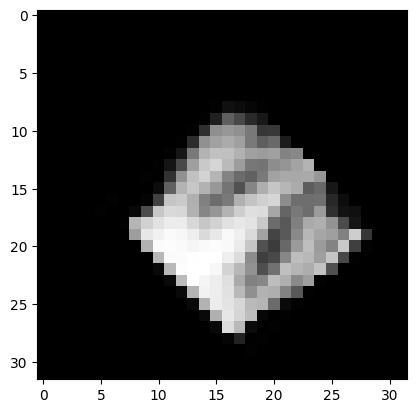

In [15]:
x_batch, y_batch = next(iter(train_DL))
print(x_batch.shape)
plt.imshow(x_batch[0].permute(1,2,0), cmap='gray')
print(test_DS.classes[y_batch[0]])

torch.Size([32, 1, 32, 32])
Positive


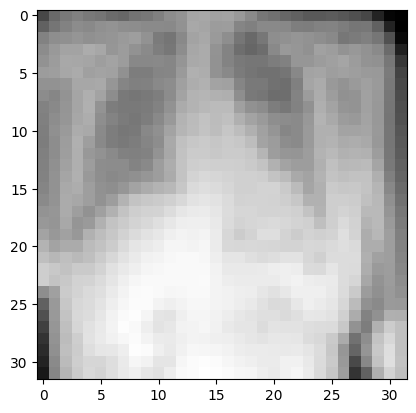

In [16]:
x_batch, y_batch = next(iter(test_DL))
print(x_batch.shape)
plt.imshow(x_batch[0].permute(1,2,0), cmap='gray')
print(test_DS.classes[y_batch[0]])